**Task 1:**

Load the dataset into a pandas DataFrame using pd.read_csv() (or equivalent).

Print the first five rows, the column data types (.dtypes), and the DataFrame shape.

In [14]:
# Import essential libraries before performing Data Acquisition, Cleaning, and Exploratory Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [15]:
# load diamonds dataset from the seaborn library
df = sns.load_dataset("diamonds")

In [16]:
# print first 5 rows
# use .head() function for this
# default value is 5
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [17]:
# check the datatype of each column
df.dtypes

,0
carat,float64
cut,category
color,category
clarity,category
depth,float64
table,float64
price,int64
x,float64
y,float64
z,float64


In [18]:
# check how many rows and columns are there in dataset
# first number gives count of rows
#second number gives count of columns
df.shape

(53940, 10)

Dataset contains 53940 rows and 10 columns

7 columns has numeric data type and 3 columns has string(caregory) datatype

**Task 2:**

Null value analysis:
Compute the count and percentage of missing values in every column using df.isnull().sum() and (df.isnull().sum() / df.shape[0]) * 100.

In [19]:
# count percentage of missing values in every column
# df.isnull().sum() gives the count of null values in each column
# by default when sum() applied the operation performs vertically (axis=0)
# shape[0] gives the count of total rows in dataset

(df.isnull().sum()/df.shape[0])*100

# instead of isnull() we can also use isna() both produce same results

,0
carat,0.0
cut,0.0
color,0.0
clarity,0.0
depth,0.0
table,0.0
price,0.0
x,0.0
y,0.0
z,0.0


There are 0 Null values in the dataset

In [20]:
# If there had been null values we would use a following approach to fill Null values
# assume if the below 2 columns had null values
# cols = ["y", "price"]
# for col in cols:
#   df[col].fillna(df[col].median(), inplace=True) # median used as it is not affected by outliers making dataset unbiased

**Task 3:**

Duplicate detection and removal:
Use df.duplicated().sum() to count duplicates.
Remove them with df.drop_duplicates().
Report how many rows were removed and whether the removal changes any column's null percentage.

In [21]:
# count number of duplicates in the dataset
# duplicated() gives a boolean mask of True and False
# by default the second occurance of the same data is considered as duplicate(True)
# sum() is then used to count how many duplicates exist : True = 1 False = 0
df.duplicated().sum()

np.int64(146)

There are 146 duplicate rows

In [22]:
# drop the duplicates
df.drop_duplicates(inplace=True) # inplace=True commits changes in the existing dataframe

In [23]:
# cross verify and see are all duplicates removed or not
df.duplicated().sum()

np.int64(0)

All duplicates removed

In [24]:
# check how many rows and columns the dataset contains
# note: columns will remain same its the row number that may be affected
df.shape

(53794, 10)

Now we have 53794 rows and 10 columns in the dataset

In [25]:
# display few data (Good Practice especially after null removal / duplicate removal operations)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Task 4:**
Data type correction:
Identify at least one column whose inferred dtype is incorrect (e.g., a numeric column stored as object).
Convert it using astype() or pd.to_numeric() with errors='coerce'. Convert at least one repetitive string column to category dtype.
Report memory usage before and after the conversion using df.memory_usage(deep=True).sum().

the dataset contains no columns with incorrect datatype

In [26]:
# however below is sample example to understand how to deal in such situations
# suppose if would had column carat which would have some string like 'NULL' this would have made it string type
# simply use df['carat']=pd.to_numeric(errors='coerce)
# this converts the column into numeric and wherever a string is detected in that column it is automaticallu converted to NULL(NaN)
# next step is to see how many nulls are there if very low count good to ommit that row itself else fill the nulls with the median of that column.
# Median is chosen as it is not affected by outliers
# suppose if we would have 3 repeated string columns which were not of category data type
# below approach would have been useful in such cases

before = df.memory_usage(deep=True).sum()

col = ['cut', 'clarity', 'color']
for i in col:
    df[i] = df[i].astype('category')

after = df.memory_usage(deep=True).sum()

print("Before:", before)
print("After :", after)
print("Memory Saved:", before - after)

Before: 3606010
After : 3606010
Memory Saved: 0


In [27]:
# After datatype conversion cross verify to check data types
df.dtypes

,0
carat,float64
cut,category
color,category
clarity,category
depth,float64
table,float64
price,int64
x,float64
y,float64
z,float64


**Task 5:**

Descriptive statistics and skewness:
Call df.describe() on all numeric columns.
For each numeric column, compute df[col].skew().
Identify and name the column with the highest absolute skewness.

In [28]:
# identify numeric columns
numeric_col=['carat','depth','table','price','x','y','z']
# print statistical summary
df[numeric_col].describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [29]:
# check skew of each column
# Skewness tells you whether the data is evenly distributed or stretched more on one side.
# skew can be positive as well as negative
df[numeric_col].skew()


,0
carat,1.113651
depth,-0.114250
table,0.792227
price,1.618240
x,0.379624
y,2.445768
z,1.529023


If value between -1 to 1 we do not consider it too much skew

If value > 1 then skewed is introducted meaning data in that column is skewed

Carat and y columns have huge skewness

**Task 6:**

Outlier detection with IQR:
For at least two numeric columns, compute Q1 (df[col].quantile(0.25)), Q3 (df[col].quantile(0.75)), IQR = Q3 − Q1, lower bound = Q1 − 1.5 × IQR,
and upper bound = Q3 + 1.5 × IQR.
Count the number of rows that fall outside these bounds.


In [30]:
columns = ["carat", "price"]

for col in columns:

    Q1 = df[col].quantile(0.25) # gives Q25
    Q3 = df[col].quantile(0.75) # gives Q75

    IQR = Q3 - Q1 # formula for Interquartile Range

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)] #values that does not meet this range are considered as outliers

    print(f"\nColumn : {col}")
    print(f"Q1 : {Q1:.2f}")
    print(f"Q3 : {Q3:.2f}")
    print(f"IQR : {IQR:.2f}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"Number of Outliers : {len(outliers)}")


Column : carat
Q1 : 0.40
Q3 : 1.04
IQR : 0.64
Lower Bound : -0.56
Upper Bound : 2.00
Number of Outliers : 1873

Column : price
Q1 : 951.00
Q3 : 5326.75
IQR : 4375.75
Lower Bound : -5612.62
Upper Bound : 11890.38
Number of Outliers : 3523


**Task 7:**

Visualizations:
1) A line plot of one numeric variable sorted by row index or time column (use plt.plot()). Add a title, x-label, and y-label.
2) A bar chart comparing the mean of one numeric column across categories of one categorical column (use plt.bar() or df.groupby().mean().plot.bar()).
Add a title and axis labels.
3) A histogram of the most skewed numeric column identified in Task 5 (use sns.histplot() with bins=20).
Add a title and describe the shape of the distribution in the README.
4) A scatter plot between two numeric columns that you expect to be correlated (use sns.scatterplot()).
Add a title and interpret the direction and approximate strength of the relationship in the README.
5) A box plot of a numeric column split by a categorical column (use sns.boxplot()).
Add a title and describe any visible differences in median and spread across categories.

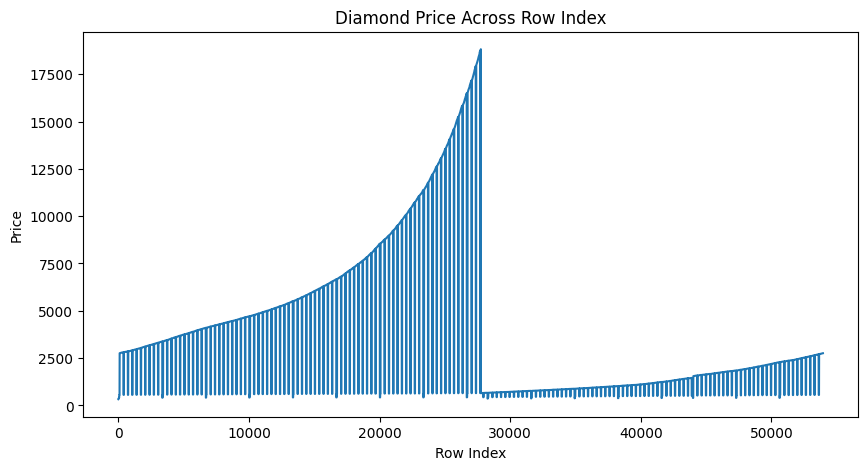

In [31]:
# line plot
# best suited when data related to time
plt.figure(figsize=(10,5))

plt.plot(df.index, df["price"])

plt.title("Diamond Price Across Row Index")
plt.xlabel("Row Index")
plt.ylabel("Price")

plt.show()

/tmp/ipykernel_944/2850278485.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_price = df.groupby("cut")["price"].mean()


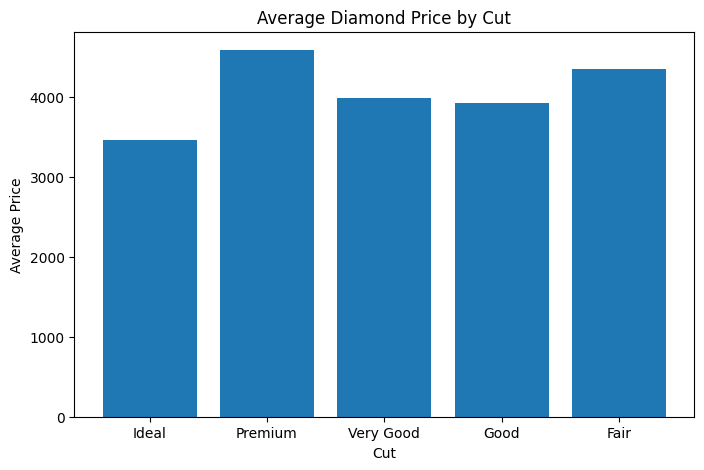

In [32]:
# bar plot
# best suited for category vs numeric
mean_price = df.groupby("cut")["price"].mean()

plt.figure(figsize=(8,5))

plt.bar(mean_price.index, mean_price.values)

plt.title("Average Diamond Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")

plt.show()

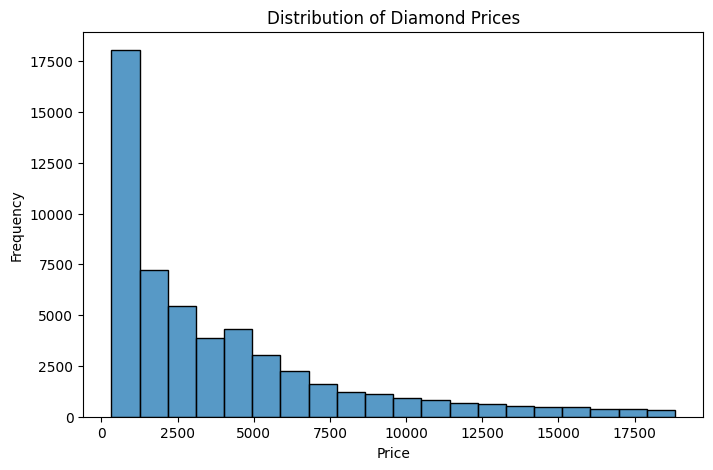

In [33]:
# Histogram plot

plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=20) # reqirues only one variable and that too numeric

plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

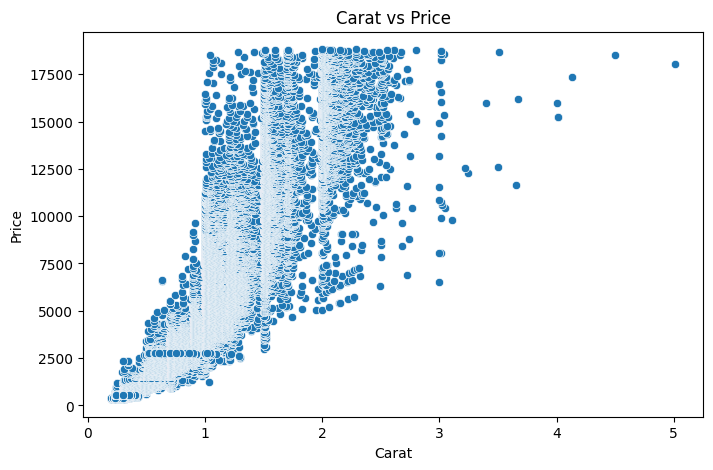

In [34]:
# Scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="carat",
                y="price") # both variables should be numeric

plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.show()

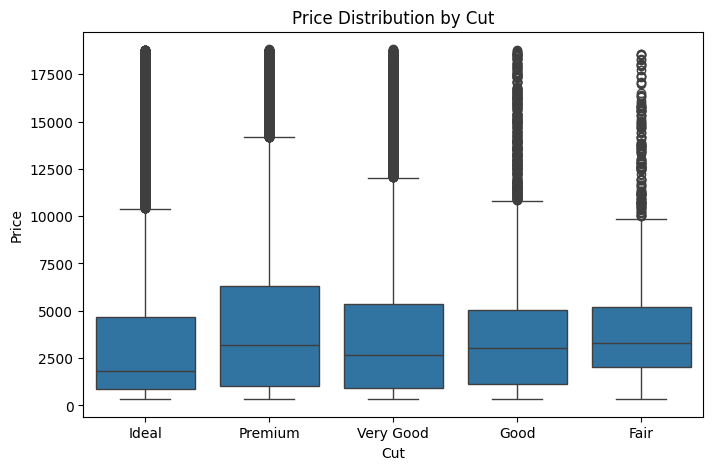

In [35]:
# Box plot
# used to detect outliers
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="cut",
            y="price")

plt.title("Price Distribution by Cut")
plt.xlabel("Cut")
plt.ylabel("Price")

plt.show()

**Task 8:**

Correlation heat map:
Compute the correlation matrix of all numeric columns using df.corr().
Visualize it with a heat map (use sns.heatmap() with annot=True).
Identify the pair of variables with the highest absolute correlation.

          carat     depth     table     price         x         y         z
carat  1.000000  0.027861  0.181091  0.921548  0.975380  0.951908  0.953542
depth  0.027861  1.000000 -0.297669 -0.011048 -0.025348 -0.029389  0.094757
table  0.181091 -0.297669  1.000000  0.126566  0.194855  0.183231  0.150270
price  0.921548 -0.011048  0.126566  1.000000  0.884504  0.865395  0.861208
x      0.975380 -0.025348  0.194855  0.884504  1.000000  0.974592  0.970686
y      0.951908 -0.029389  0.183231  0.865395  0.974592  1.000000  0.951844
z      0.953542  0.094757  0.150270  0.861208  0.970686  0.951844  1.000000


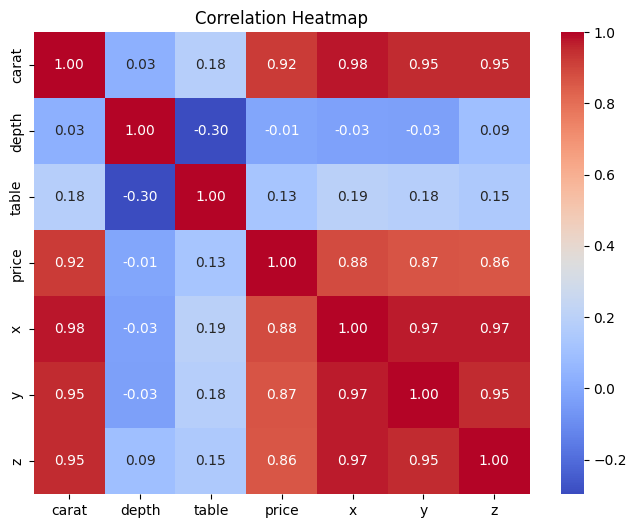

In [36]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [37]:
# highest absolute correlation
corr = df.corr(numeric_only=True).abs()

# Remove diagonal
np.fill_diagonal(corr.values, 0)

highest_pair = corr.stack().idxmax()
highest_value = corr.stack().max()

print("Highest Correlated Pair:", highest_pair)
print("Correlation:", highest_value)

Highest Correlated Pair: ('carat', 'x')
Correlation: 0.9753796376444227


carat & x are the pair of variables with the highest absolute correlation.

**Task 9a:**

Imputation strategy comparison:
For the two numeric columns with the highest absolute skewness,
compute both the column mean (df[col].mean()) and the column median (df[col].median()) before any imputation is applied to those columns.
Print both values side by side for each column.

y=2.445768 & price=1.618240

These are the two highest absolute skewness values.

In [38]:
# Imputation strategy

cols = ["y", "price"]

for col in cols:

  print(f"\nColumn : {col}")
  print("Mean   :", df[col].mean())
  print("Median :", df[col].median())


Column : y
Mean   : 5.734653307060266
Median : 5.71

Column : price
Mean   : 3933.065081607614
Median : 2401.0


**Task 9b:**

Spearman rank correlation:
 pearman correlation is a rank-based measure — it converts each column's values to their ranks (1st, 2nd, 3rd, …)
 and then computes the standard Pearson correlation on those ranks.
 Because it operates on ranks rather than raw values, it captures monotonic relationships (values move together consistently,
 but not necessarily proportionally) that Pearson can miss. Use df.corr(method='spearman') and compare the result to your Pearson matrix  —
 a column pair where |Spearman| > |Pearson| indicates a consistent but non-linear relationship between those two variables.
 Compute the Spearman rank correlation matrix for all numeric columns using df.corr(method='spearman').
 Identify the three column pairs where the absolute difference between the Spearman correlation and the Pearson correlation  is largest.
 Print both matrices and a difference table showing |Spearman − Pearson| for each pair.

In [39]:
# Pearson correlation matrix
pearson = df.corr(numeric_only=True)

# Spearman correlation matrix
spearman = df.corr(method="spearman", numeric_only=True)

print("Pearson Correlation Matrix")
print(pearson)

print("\nSpearman Correlation Matrix")
print(spearman)

# Create comparison table
pairs = []

columns = pearson.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        col1 = columns[i]
        col2 = columns[j]

        p = pearson.loc[col1, col2]
        s = spearman.loc[col1, col2]

        pairs.append({
            "Column 1": col1,
            "Column 2": col2,
            "Pearson": round(p, 4),
            "Spearman": round(s, 4),
            "|Spearman - Pearson|": round(abs(s - p), 4)
        })

difference_table = pd.DataFrame(pairs)

difference_table = difference_table.sort_values(
    by="|Spearman - Pearson|",
    ascending=False
)

print("\nDifference Table")
print(difference_table)

print("\nTop 3 Column Pairs")
print(difference_table.head(3))

Pearson Correlation Matrix
          carat     depth     table     price         x         y         z
carat  1.000000  0.027861  0.181091  0.921548  0.975380  0.951908  0.953542
depth  0.027861  1.000000 -0.297669 -0.011048 -0.025348 -0.029389  0.094757
table  0.181091 -0.297669  1.000000  0.126566  0.194855  0.183231  0.150270
price  0.921548 -0.011048  0.126566  1.000000  0.884504  0.865395  0.861208
x      0.975380 -0.025348  0.194855  0.884504  1.000000  0.974592  0.970686
y      0.951908 -0.029389  0.183231  0.865395  0.974592  1.000000  0.951844
z      0.953542  0.094757  0.150270  0.861208  0.970686  0.951844  1.000000

Spearman Correlation Matrix
          carat     depth     table     price         x         y         z
carat  1.000000  0.030288  0.194166  0.962924  0.996161  0.995614  0.993255
depth  0.030288  1.000000 -0.245194  0.010181 -0.023273 -0.025247  0.103651
table  0.194166 -0.245194  1.000000  0.171025  0.201466  0.194952  0.159105
price  0.962924  0.010181  0.171

**Task 9c:**

Grouped aggregation:
Choose one categorical column and one numeric column from the cleaned dataset.
 Compute df.groupby(categorical_col)[numeric_col].agg(['mean', 'std', 'count']) and print the result.
 name the group with the highest mean and the group with the highest standard deviation;
 compute the ratio of the highest group mean to the lowest group mean.

In [40]:
# grouped aggregation
group = df.groupby("cut")["price"].agg(
    ["mean","std","count"]
)

print(group)

                  mean          std  count
cut                                       
Ideal      3462.749953  3810.926394  21488
Premium    4583.501891  4348.052680  13748
Very Good  3981.016157  3934.813175  12069
Good       3919.121039  3671.070930   4891
Fair       4341.954318  3540.118138   1598


/tmp/ipykernel_944/3058399675.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby("cut")["price"].agg(


In [41]:
# highest mean
print(group.sort_values(by="mean", ascending=False).head(1))


                mean         std  count
cut                                    
Premium  4583.501891  4348.05268  13748


In [42]:
# highest standard deviation
print(group.sort_values(by="std", ascending=False).head(1))


                mean         std  count
cut                                    
Premium  4583.501891  4348.05268  13748


In [43]:
#highest to lowest ratio
ratio = group["mean"].max()/group["mean"].min()

print("Ratio =", ratio)

Ratio = 1.3236595055329181


**Task 10:**
Save the clean dataset to a file named cleaned_data.csv using df.to_csv('cleaned_data.csv', index=False).

In [44]:

df.to_csv("cleaned_data.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
